<a href="https://colab.research.google.com/github/Zheltov/PT_ML/blob/main/ML_PTCourse_MicroHT1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Микро-ДЗ 1: Знакомство с машинным обучением

## Описание задачи и загрузка данных

В этом задании вам нужно обучить линейную регрессию для предсказания стоимости домов в Калифорнии.

Альтернативная задача: прогноз стоимости алмазов.

Рекомендуем решать ее после выполнения этого ноутбука. Предоставим только данные, а пайплайн надо будет воспроизвести самостоятельно.

[Ссылка на данные.](https://raw.githubusercontent.com/aiedu-courses/stepik_eda_and_dev_tools/main/datasets/diamonds_good.csv)

Загружаем необходимые библиотеки.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/aiedu-courses/stepik_eda_and_dev_tools/main/datasets/diamonds_good.csv")

Фиксируем `random_state` для воспроизводимости случайных значений.

In [2]:
RANDOM_STATE = 42

Загрузим данные и сформируем из них матрицу объект-признак `X` и вектор `y`, содержащий целевую переменную.

In [3]:
df.head()

,carat,cut,color,clarity,depth,table,price,'x','y','z'
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


In [11]:
# заменим все перечисления на колонки

df_t = df.copy()
df_t['cut'] = df_t['cut'].str.replace('Goood','Good')
df_t = pd.get_dummies(df_t, columns=['cut'], dtype = int)
df_t = pd.get_dummies(df_t, columns=['color'], dtype = int)
df_t = pd.get_dummies(df_t, columns=['clarity'], dtype = int)

df_t.head()

,carat,depth,table,price,'x','y','z',cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326.0,3.95,3.98,2.43,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326.0,3.89,3.84,2.31,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327.0,4.05,4.07,2.31,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334.0,4.20,4.23,2.63,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335.0,4.34,4.35,2.75,0,1,0,...,0,1,0,0,0,1,0,0,0,0


In [22]:
df_t.describe()

,carat,depth,table,price,'x','y','z',cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
count,53442.000000,52950.000000,53940.000000,53940.000000,53940.000000,53935.000000,53940.000000,53940.000000,53940.000000,53940.000000,...,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797561,61.749422,57.457184,3932.799722,5.731157,5.734469,3.538734,0.029811,0.092269,0.399036,...,0.100519,0.052058,0.013737,0.033185,0.242214,0.170449,0.151483,0.227253,0.067760,0.093919
std,0.473534,1.431558,2.234491,3989.439738,1.121761,1.142125,0.705699,0.170067,0.289408,0.489705,...,0.300694,0.222146,0.116400,0.179121,0.428427,0.376030,0.358522,0.419061,0.251337,0.291719
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Очистим данные от выбросов**

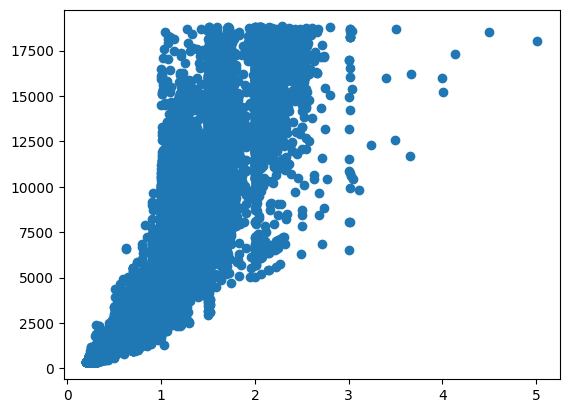

In [27]:
# carat

from matplotlib import pyplot as plt

plt.scatter(df_t["carat"], df_t['price'])

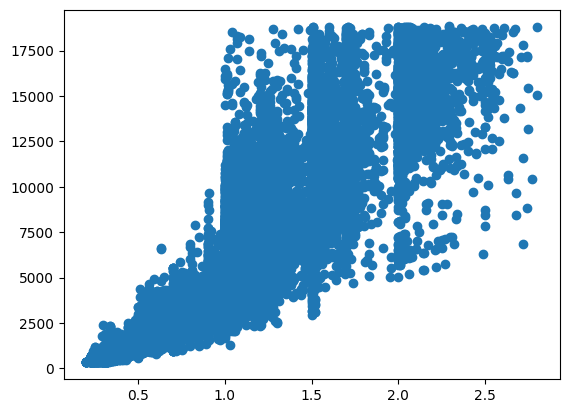

In [29]:
df_t = df_t[df_t['carat'] < 3]
plt.scatter(df_t["carat"], df_t['price'])

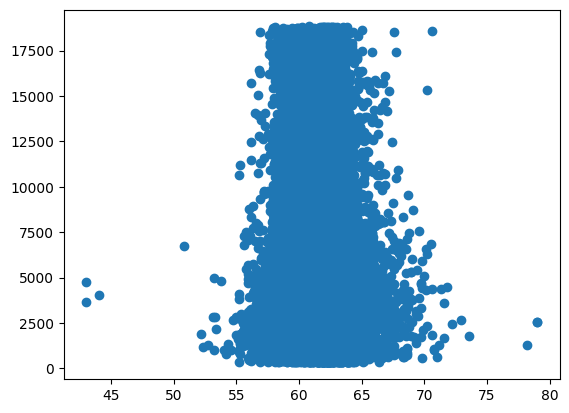

In [30]:
# depth
plt.scatter(df_t["depth"], df_t['price'])

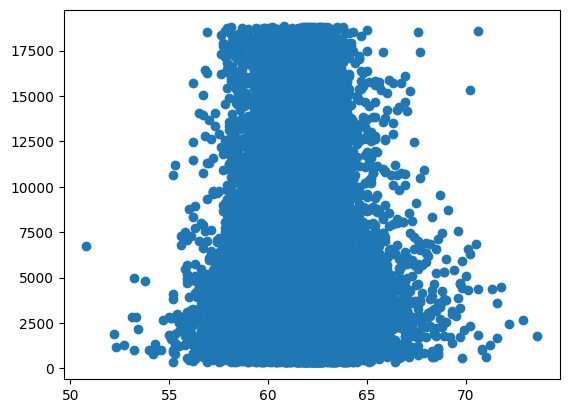

In [32]:
df_t = df_t[df_t['depth'] > 50]
df_t = df_t[df_t['depth'] < 75]
plt.scatter(df_t["depth"], df_t['price'])

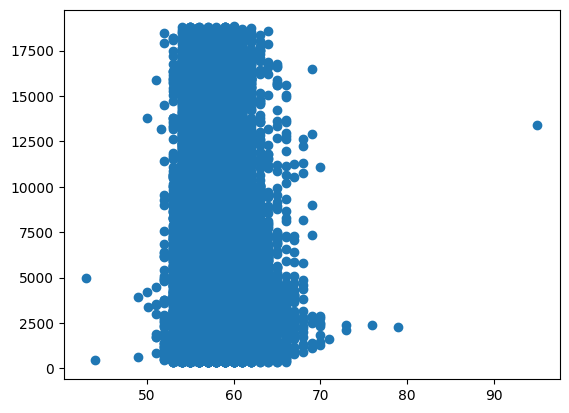

In [33]:
# carat
plt.scatter(df_t["table"], df_t['price'])

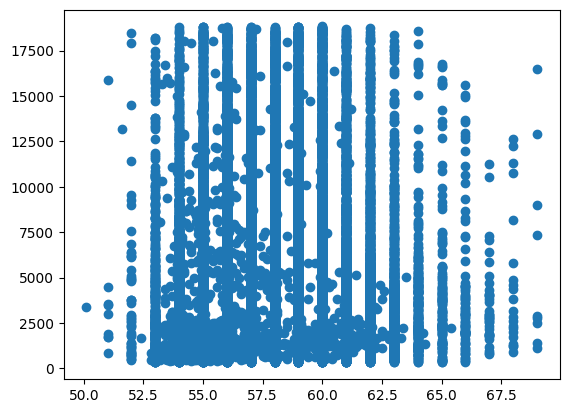

In [34]:
df_t = df_t[df_t['table'] > 50]
df_t = df_t[df_t['table'] < 70]
plt.scatter(df_t["table"], df_t['price'])

In [ ]:
Явно видна структура вертикальных линий и какой-то шум, нужно ли с ним что-то делать?

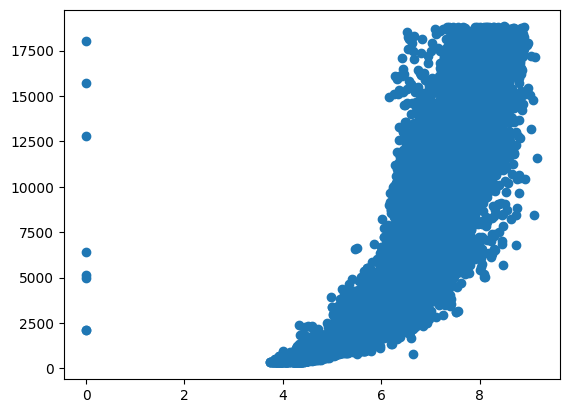

In [35]:
# x
plt.scatter(df_t["'x'"], df_t['price'])

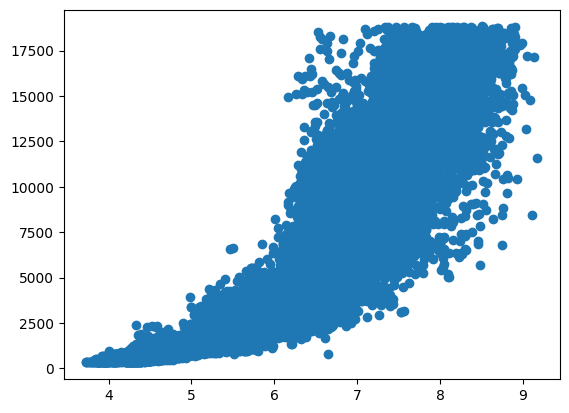

In [36]:
df_t = df_t[df_t["'x'"] > 3]
plt.scatter(df_t["'x'"], df_t['price'])

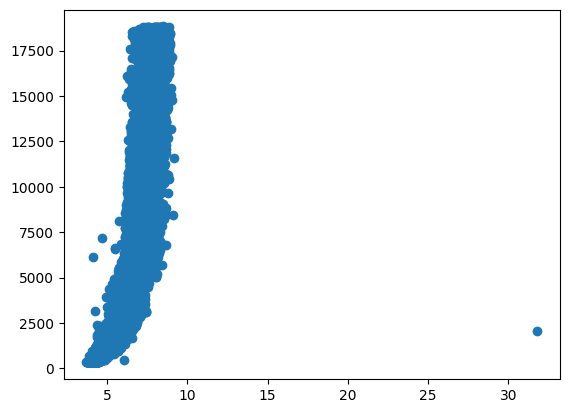

In [37]:
# y
plt.scatter(df_t["'y'"], df_t['price'])

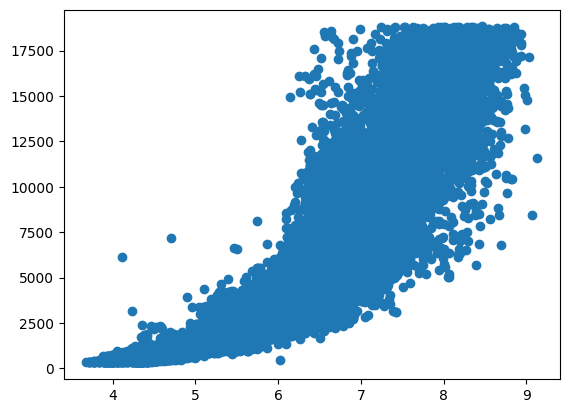

In [38]:
df_t = df_t[df_t["'y'"] < 10]
plt.scatter(df_t["'y'"], df_t['price'])

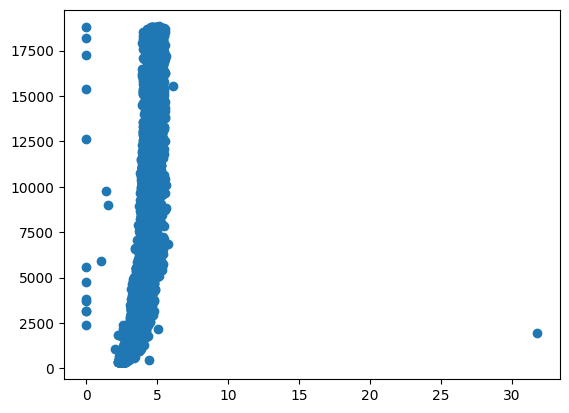

In [39]:
# z
plt.scatter(df_t["'z'"], df_t['price'])

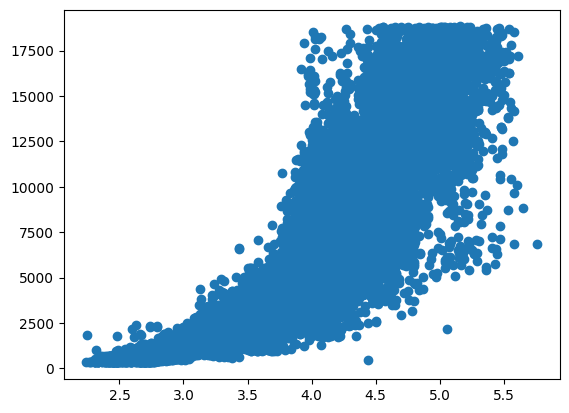

In [48]:
df_t = df_t[df_t["'z'"] > 2.1]
df_t = df_t[df_t["'z'"] < 6]
plt.scatter(df_t["'z'"], df_t['price'])

In [51]:
print(f"df_t/df size: {df_t.shape} / {df.shape}")

df_t/df size: (52363, 27) / (53940, 10)


In [55]:
X = df_t.drop(['price'], axis=1)
y = df_t['price']

Обучим модель

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

model = LinearRegression()

model.fit(Xtrain, ytrain)

LinearRegression()

In [61]:
pred = model.predict(Xtest)
pred[:10]

array([3016.20192871, 7428.79963291,  657.28765013, 9190.64156736,
        482.05055801, 3290.14683127, 2402.19472263,  993.55505303,
       4020.18165501, 1858.54956558])

In [62]:
ytest[:10].values

array([ 2422., 11365.,   990.,  7103.,   619.,  2583.,  1697.,   746.,
        3806.,  2313.])

In [64]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

mse = mean_squared_error(ytest, pred)
p = mean_absolute_percentage_error(ytest, pred)

print(f"mean_absolute_percentage_error: {p}")

mean_absolute_percentage_error: 0.3815653246519146


Результат так себе

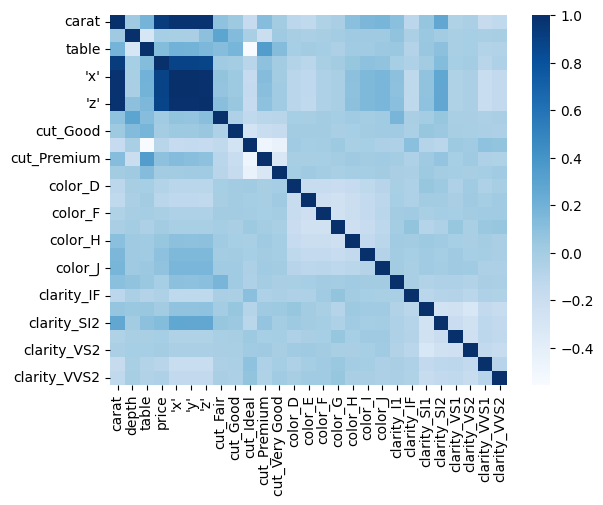

In [71]:
corr = df_t.corr()
sb.heatmap(corr, cmap="Blues");

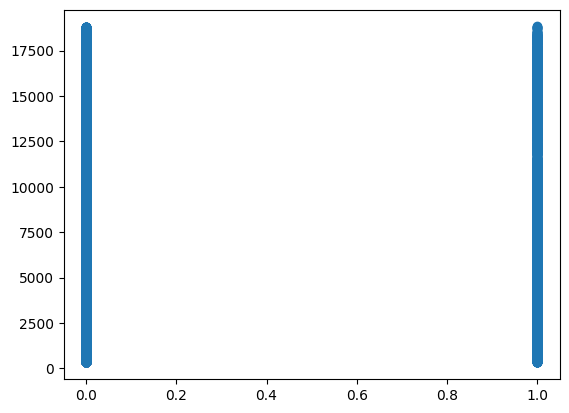

In [74]:
plt.scatter(df_t["color_I"], df_t['price'])

Т.е. у нас во всех ценовых диапозонах есть алмазы всех ценовых категорий, т.е. признак ценности вообще не несет?
Аналогично и со всеми остальными. Может их выкинуть вообще?

Вернемся в самое начало и выбросим признаки: cut, color, clarity

In [77]:
df_t2 = df.copy()
df_t2 = df_t2.drop(['cut', 'color', 'clarity'], axis=1)

# почистим данные
df_t2 = df_t2[df_t2['carat'] < 3]
df_t2 = df_t2[df_t2['depth'] > 50]
df_t2 = df_t2[df_t2['depth'] < 75]
df_t2 = df_t2[df_t2['table'] > 50]
df_t2 = df_t2[df_t2['table'] < 70]
df_t2 = df_t2[df_t2["'x'"] > 3]
df_t2 = df_t2[df_t2["'y'"] < 10]
df_t2 = df_t2[df_t2["'z'"] > 2.1]
df_t2 = df_t2[df_t2["'z'"] < 6]


In [81]:
X = df_t2.drop(['price'], axis=1)
y = df_t2['price']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

model = LinearRegression()

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

In [82]:
p = mean_absolute_percentage_error(ytest, pred)

print(f"mean_absolute_percentage_error: {p}")

mean_absolute_percentage_error: 0.26526685673469225


Вау, уже лучше!

Прочитал в чатике что x,y,z сильно скорелированы и лучше их выкинуть.

In [86]:
df_t3 = df_t2.copy()
df_t3 = df_t3.drop(["'x'", "'y'", "'z'"], axis=1)
df_t3.head()

,carat,depth,table,price
0,0.23,61.5,55.0,326.0
1,0.21,59.8,61.0,326.0
2,0.23,56.9,65.0,327.0
3,0.29,62.4,58.0,334.0
4,0.31,63.3,58.0,335.0


In [87]:
X = df_t3.drop(['price'], axis=1)
y = df_t3['price']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

model = LinearRegression()

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

In [88]:
p = mean_absolute_percentage_error(ytest, pred)

print(f"mean_absolute_percentage_error: {p}")

mean_absolute_percentage_error: 0.40314405577190743


Неа, стало хуже